# 01 Toast POS Sales EDA

Explore the one-month item-level sales export: trends, category mix, concentration, daypart patterns, and modifier behavior.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT / 'notebooks' / 'lib'))

import pantry_eda as eda

pd = eda.pd
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 100)

sales = eda.read_pos_item_selections()
modifiers = eda.read_pos_modifiers()
product_mix = eda.read_product_mix_export()
sales.head()

,order,sent_date,menu_item,menu_group,menu,sales_category,net_price,qty,void,sent_at,business_date,hour,day_name,is_void,menu_item_key
0,1,4/1/26 5:02 PM,Mountain Valley Spring,NA BEV,BEV,NA Beverage,10.0,1.0,False,2026-04-01 17:02:00,2026-04-01,17,Wednesday,False,mountain valley spring
1,1,4/1/26 5:03 PM,Tokyo Story,COCKTAILS,BEV,Liquor,17.0,1.0,False,2026-04-01 17:03:00,2026-04-01,17,Wednesday,False,tokyo story
2,2,4/1/26 5:04 PM,Noriko Oyster,STARTERS,FOOD,Food,30.0,5.0,False,2026-04-01 17:04:00,2026-04-01,17,Wednesday,False,noriko oyster
3,2,4/1/26 5:04 PM,Nori Chips & Dip,STARTERS,FOOD,Food,11.0,1.0,False,2026-04-01 17:04:00,2026-04-01,17,Wednesday,False,nori chips dip
4,2,4/1/26 5:04 PM,Salmon Crudo,STARTERS,FOOD,Food,12.0,1.0,False,2026-04-01 17:04:00,2026-04-01,17,Wednesday,False,salmon crudo


## Jan-Apr Product Mix Export

The longer Product Mix export is useful for broad category/menu mix, but the current files are aggregate reports rather than daily rows.

In [ ]:
pd.DataFrame([
    {
        'file': name,
        'rows': len(frame),
        'columns': frame.shape[1],
        'has_daily_granularity': eda.product_mix_has_daily_granularity(frame),
    }
    for name, frame in product_mix.items()
])

In [ ]:
product_mix.get('All levels.csv')

## Topline

In [2]:
pd.DataFrame([{
    'rows': len(sales),
    'date_min': sales['business_date'].min(),
    'date_max': sales['business_date'].max(),
    'total_qty': sales['qty'].sum(),
    'net_sales': sales['net_price'].sum(),
    'unique_items': sales['menu_item_key'].nunique(),
    'unique_orders': sales['order'].nunique(),
}])

,rows,date_min,date_max,total_qty,net_sales,unique_items,unique_orders
0,12696,2026-04-01,2026-04-30,13492.0,166173.2,128,60


## Daily Sales Trend

In [3]:
daily = eda.daily_sales(sales)
daily['avg_qty_per_order'] = daily['qty'] / daily['orders']
daily

,business_date,qty,net_sales,orders,avg_qty_per_order
0,2026-04-01,468.0,5731.00,37,12.648649
1,2026-04-02,337.0,3755.51,35,9.628571
2,2026-04-03,622.0,7726.01,48,12.958333
3,2026-04-04,618.0,7324.25,43,14.372093
4,2026-04-05,413.0,4981.50,42,9.833333
5,2026-04-06,406.0,4501.00,22,18.454545
6,2026-04-07,478.0,5240.01,26,18.384615
7,2026-04-08,348.0,4959.00,36,9.666667
8,2026-04-09,443.0,5306.50,38,11.657895
9,2026-04-10,518.0,6543.51,50,10.360000


Matplotlib is building the font cache; this may take a moment.


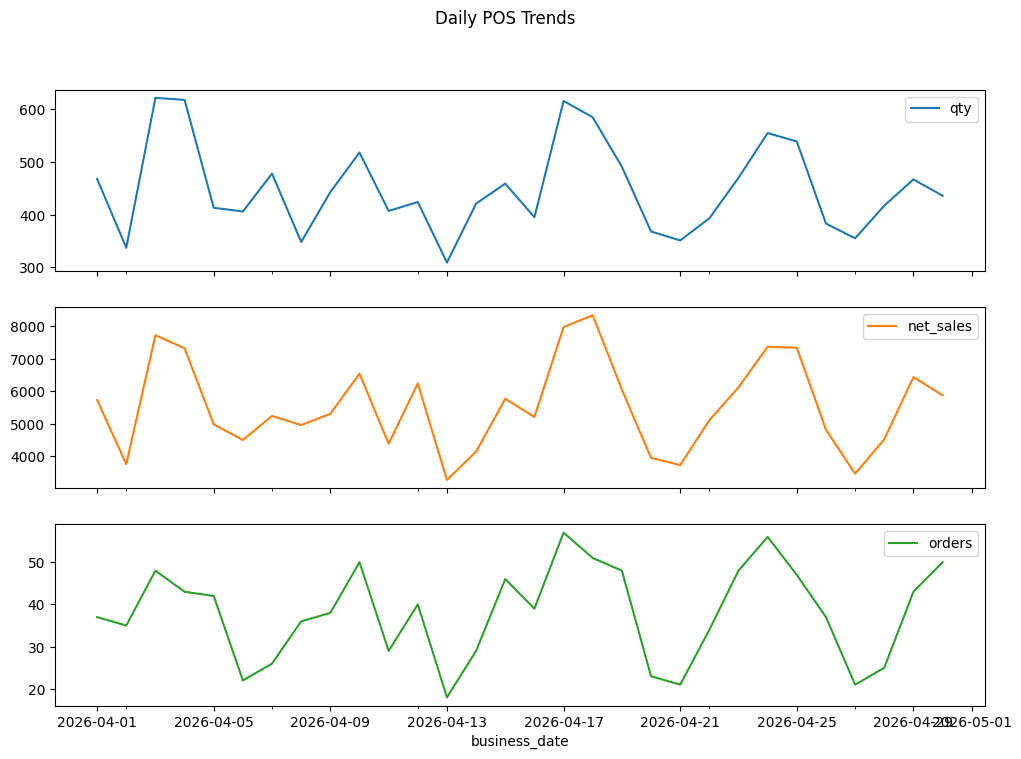

In [4]:
daily.set_index('business_date')[['qty', 'net_sales', 'orders']].plot(subplots=True, figsize=(12, 8), title='Daily POS Trends');

## Day Of Week Patterns

In [5]:
dow = sales.copy()
dow['weekday'] = pd.to_datetime(dow['business_date']).dt.day_name()
dow_summary = (
    dow.groupby('weekday', as_index=False)
    .agg(qty=('qty', 'sum'), net_sales=('net_price', 'sum'), orders=('order', 'nunique'))
)
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_summary['weekday'] = pd.Categorical(dow_summary['weekday'], categories=weekday_order, ordered=True)
dow_summary.sort_values('weekday')

,weekday,qty,net_sales,orders
1,Monday,1438.0,15183.01,25
5,Tuesday,1667.0,17630.01,30
6,Wednesday,2135.0,27998.30,49
4,Thursday,2081.0,26266.01,51
0,Friday,2311.0,29616.02,60
2,Saturday,2149.0,27391.85,56
3,Sunday,1711.0,22088.00,50


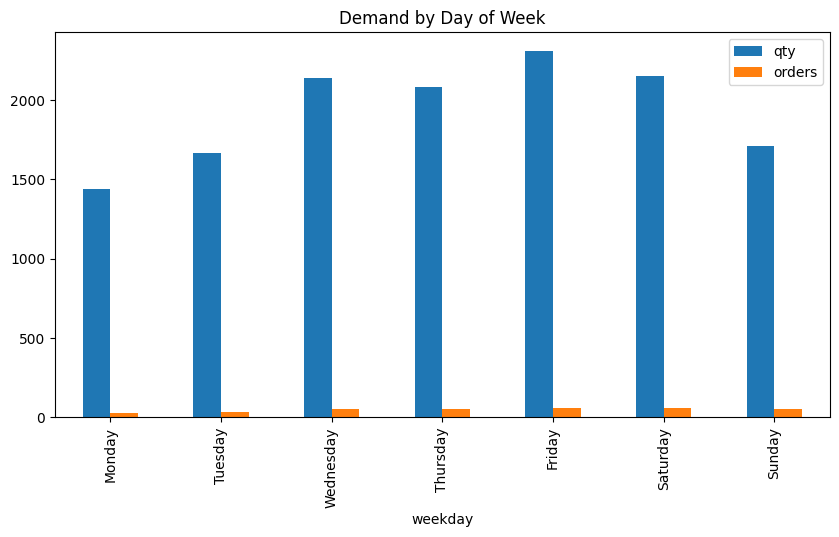

In [6]:
dow_summary.sort_values('weekday').plot(x='weekday', y=['qty', 'orders'], kind='bar', figsize=(10, 5), title='Demand by Day of Week');

## Category Mix

In [7]:
category = (
    sales.groupby('sales_category', as_index=False)
    .agg(qty=('qty', 'sum'), net_sales=('net_price', 'sum'), items=('menu_item_key', 'nunique'))
    .sort_values('qty', ascending=False)
)
category['qty_share'] = category['qty'] / category['qty'].sum()
category

,sales_category,qty,net_sales,items,qty_share
1,Food,11410.0,133911.98,73,0.845686
2,Liquor,1075.0,18027.21,23,0.079677
4,Wine/Sake,522.0,9949.01,22,0.038690
3,NA Beverage,287.0,2351.00,10,0.021272
0,Beer,198.0,1934.00,4,0.014675


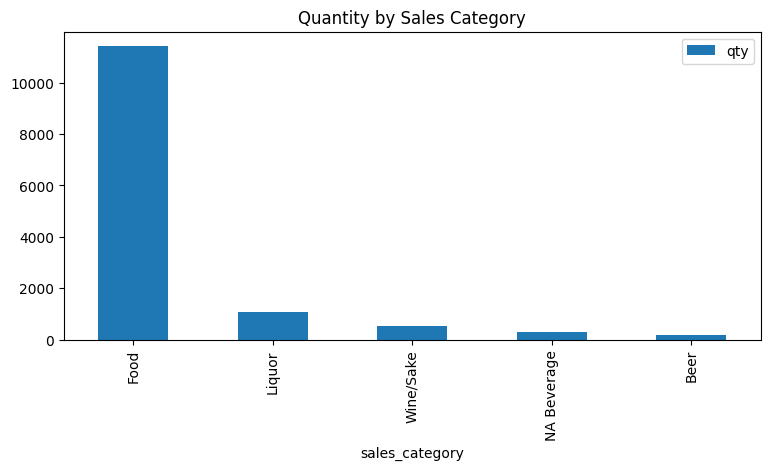

In [8]:
category.plot(x='sales_category', y='qty', kind='bar', figsize=(9, 4), title='Quantity by Sales Category');

## Item Concentration

This is useful because recipes for the top demand drivers unlock the majority of inventory signal.

In [9]:
items = eda.top_items(sales, n=200)
items['qty_share'] = items['qty'] / sales['qty'].sum()
items['cumulative_qty_share'] = items['qty_share'].cumsum()
items.head(30)

,menu_item_key,menu_item,sales_category,qty,net_sales,orders,qty_share,cumulative_qty_share
9,bluefin tuna toro,Bluefin Tuna Toro,Food,980.0,8672.77,58,0.072636,0.072636
133,yellowtail,Yellowtail,Food,934.0,2042.40,60,0.069226,0.141862
79,noriko oyster,Noriko Oyster,Food,919.0,5167.25,59,0.068114,0.209976
12,california,California,Food,865.0,1470.40,59,0.064112,0.274088
4,bay scallop dynamite,Bay Scallop Dynamite,Food,666.0,3730.24,59,0.049363,0.323451
78,nori chips dip,Nori Chips & Dip,Food,573.0,6044.55,60,0.042470,0.365921
8,bluefin tuna poke,Bluefin Tuna Poke,Food,513.0,1459.80,58,0.038023,0.403943
26,crab motoyaki,Crab Motoyaki,Food,359.0,4365.06,55,0.026608,0.430551
18,chefs set,CHEFS SET,Food,347.0,14796.80,55,0.025719,0.456270
16,chef special edmund fitzgerald,Chef Special: Edmund Fitzgerald,Food,345.0,4625.36,58,0.025571,0.481841


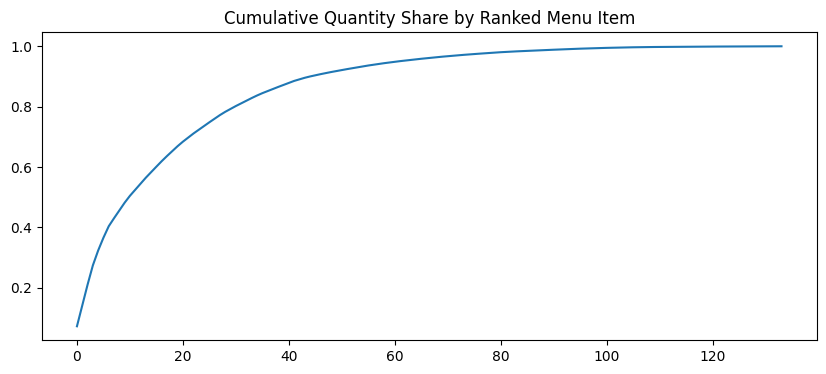

In [10]:
items.reset_index(drop=True)['cumulative_qty_share'].plot(figsize=(10, 4), title='Cumulative Quantity Share by Ranked Menu Item');

## Daypart / Hourly Shape

In [11]:
hourly = (
    sales.groupby(['hour', 'sales_category'], as_index=False)
    .agg(qty=('qty', 'sum'), net_sales=('net_price', 'sum'))
)
hourly_pivot = hourly.pivot_table(index='hour', columns='sales_category', values='qty', aggfunc='sum').fillna(0)
hourly_pivot

sales_category,Beer,Food,Liquor,NA Beverage,Wine/Sake
hour,,,,,
0,0.0,1.0,0.0,0.0,0.0
9,0.0,2.0,0.0,0.0,0.0
10,0.0,2.0,0.0,0.0,0.0
11,0.0,2.0,0.0,0.0,0.0
12,0.0,5.0,0.0,0.0,0.0
13,0.0,4.0,0.0,0.0,0.0
15,0.0,7.0,0.0,0.0,2.0
16,0.0,29.0,0.0,0.0,0.0
17,38.0,2895.0,211.0,92.0,90.0


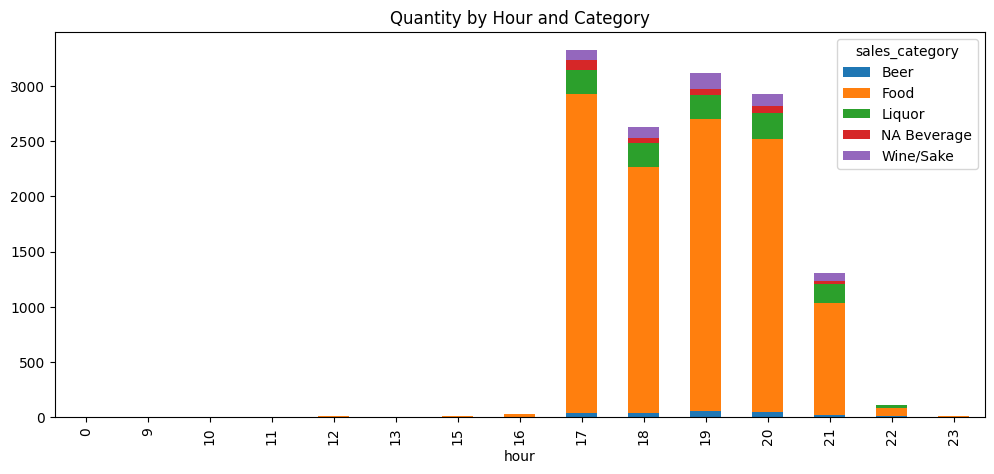

In [12]:
hourly_pivot.plot(kind='bar', stacked=True, figsize=(12, 5), title='Quantity by Hour and Category');

## Modifier Signals

In [13]:
modifier_summary = (
    modifiers.groupby(['modifier_key', 'modifier', 'option_group_name'], as_index=False)
    .agg(qty=('qty', 'sum'), net_sales=('net_price', 'sum'), parent_items=('parent_menu_selection_key', 'nunique'))
    .sort_values('qty', ascending=False)
)
modifier_summary.head(30)

,modifier_key,modifier,option_group_name,qty,net_sales,parent_items
48,second order,--SECOND ORDER--,KITCHEN MESSAGE,290.0,0.0,30
42,on us,--ON US--,KITCHEN MESSAGE,138.0,0.0,17
1,2 glass,2 Glass,GLASS PREFERENCE,99.0,0.0,11
17,dont make,--DONT MAKE--,BAR MESSAGE,70.0,0.0,22
0,1 glass,1 Glass,GLASS PREFERENCE,55.0,0.0,9
18,dont make,--DONT MAKE--,KITCHEN MESSAGE,38.0,0.0,11
23,hokkaido uni,Hokkaido Uni,Hokkaido Uni Upgrade,35.0,700.0,1
25,lite rice,--LITE RICE--,FOOD MODS,28.0,0.0,15
56,uni,Uni,LUXE UPGRADE - DINE IN,27.0,456.0,6
40,no wasabi,No Wasabi,HANDROLL MODS,23.0,0.0,11


## Starter Correlations

With only POS data loaded, the correlations here are mostly sanity checks. Stronger model correlations come once reservations, weather, events, and purchase history are aligned by date.

In [14]:
numeric_daily = daily[['qty', 'net_sales', 'orders', 'avg_qty_per_order']]
numeric_daily.corr()

,qty,net_sales,orders,avg_qty_per_order
qty,1.000000,0.928806,0.744694,-0.228860
net_sales,0.928806,1.000000,0.870622,-0.471167
orders,0.744694,0.870622,1.000000,-0.801906
avg_qty_per_order,-0.228860,-0.471167,-0.801906,1.000000
